# Practical 1 report: preparing biological data for machine learning

**Student:** Nataliia Vytska
**Date:** 29/09/2026  
**Practical:** 1 - Data to ML-ready format

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

DATA = Path(".")
RANDOM_STATE = 100926

mice = pd.read_excel(DATA / "Data_Cortex_Nuclear.xls")
mice["mouse_id"] = mice["MouseID"].astype(str).str.rsplit("_", n=1).str[0]

meta_cols = ["MouseID", "mouse_id", "Genotype", "Treatment", "Behavior", "class"]
protein_cols = [c for c in mice.columns if c not in meta_cols]

## 2. Data-preparation readiness

Complete this section before describing modelling results.

## Scientific purpose and provenance

- [x] Is the biological question and prediction task stated clearly?
      Yes, binary classification on mice Genotype: Control vs Ts65Dn
- [x] Is the unit of observation clear (for example, patient, tissue, cell, mouse, or technical measurement)?
      Yes, the mice record
- [x] Have I recorded the data version, processing history, and transformations already applied?
      Yes: UCI data, then I processed data and got "mice" and "mice_clean" ds.

In [2]:
print("Shape:", mice.shape, "| unique mice:", mice["mouse_id"].nunique())

Shape: (1080, 83) | unique mice: 72


## Table shape and identifiers

- [x] Is the table tidy: one observation per row, one variable per column, and one value per cell?
       Yes: one row = one measurement, each protein is a separate column.
- [x] If the original assay has features in rows and samples in columns, have I transposed it into the format expected by the analysis tool?
      No need, the dataset is already in the right axises
- [x] Are row names, column names, and identifiers clear, unique, stable, and free from accidental index columns?
      Yep, MouseID is unique (got 0 duplicates), protein names are clear, no extra index columns.
- [x] Can every feature and observation be traced back to its source?
      Seems to be yes
- [x] Are the feature matrix and metadata aligned by an explicit identifier rather than by row order?
      Yes: proteins and metadata are in the same table, so each row already carries its own metadata.

In [3]:
print("Duplicate MouseID:", mice["MouseID"].duplicated().sum())
mice.head(3)

Duplicate MouseID: 0


,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class,mouse_id
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m,309
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m,309
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m,309


## Types, values, and measurement meaning

- [x] Are numerical, categorical, ordinal, text, date, and identifier columns correctly classified?
      Yes: 77 proteins are float; Genotype, Treatment, Behavior, class are categorical; MouseID and mouse_id are identifiers.
- [ ] Are units, scales, encodings, reference categories, and detection limits understood?
      As I tried to discover, partly: values are relative protein levels, units and detection limits are not docxmented.
- [x] Have I checked impossible values, inconsistent labels, unexpected categories, constant features, and extreme values?
      Yes, I checked for infinite and negative values. Labels are consistent, no constant proteins, extreme values come from one mouse (id=3484) and were kept as it can be just an outlayer.
- [x] Are normalization, scaling, log transformation, and batch-correction steps documented?
      Authors' normalization is unknown to me. I did not apply scaling, log transform or batch-orrection (scaling was used only for PCA visualization).

In [4]:
print(mice[protein_cols].dtypes.value_counts())
print("Constant proteins:", (mice[protein_cols].nunique() <= 1).sum())

float64    77
Name: count, dtype: int64
Constant proteins: 0


## Missing values

- [x] Have I detected missing values using the dataset's actual missing-value representations, not only `NaN`?
      Yes: all proteins are float, no zeros or codes like -999. Missing values are only NaN.
- [x] Have I measured missingness by row, column, group, and relevant batch or time variable?
    Yes: 1396 NaN in 49 proteins; 5 proteins have 17–26% missing; 3 rows of mouse 3426 miss 43 proteins. By genotype: Control 787, Ts65Dn 609. No batch/time variable in the data.
- [x] Do I know whether missingness is structural, technical, or plausibly related to the biology or target?
      Most likely technical
- [x] Have I justified whether to retain, remove, or impute missing values?
      Yes: I removed 5 proteins with >10% missing and 3 rows with >50% missing; imputed the rest with the median(which i see as the best of the naives methods).
- [x] If imputing, will the imputer be fitted on training data only and then applied to validation/test data?
      Yes: SimpleImputer fit on X_train, then transform on X_test.

In [5]:
mice[protein_cols].isna().sum(axis=1).groupby(mice["Genotype"]).sum()

Genotype
Control    787
Ts65Dn     609
dtype: int64

## Replicates, dependence, and grouping

- [x] Have I checked for exact duplicates and near-duplicate observations?
      Yep, and found 0 duplicates
- [x] Are observations biological replicates, technical replicates, repeated measurements, pseudo-replicates, or independent samples?
      Technical replicates: 15 rows per mouse = 5 dilutions*3 replicate spots of the same sample. Only mice are independent.
- [x] Is the independent biological unit identified by a grouping variable?
      Yes:mouse_id
- [x] Will all related observations and their derivatives remain in the same train/validation/test split?
      Yes: StratifiedGroupKFold by mouse_id
- [x] If I created augmented or synthetic observations, is their provenance recorded and reproducible?
      no synthetic or augmented data was created

In [6]:
mice.groupby("mouse_id").size().value_counts()

15    72
Name: count, dtype: int64

## Target, leakage, and study design

- [x] Is the target defined before modelling, with its classes or values checked for balance and validity?
      Yes, target = Genotype 
- [x] Have I excluded identifiers, post-outcome variables, duplicated target information, and other leakage sources from the features?
      Yes, I excluded MouseID, mouse_id (identifiers), class (codes genotype), Treatment and Behavior. X contains only protein levels.

- [x] Have I identified batch, site, plate, subject, cohort, treatment, sex, age, time, or other possible confounders?
      Yes, subject is mouse. Treatment and Behavior are experimental factors. Behavior is the strongest signal on PCA. No batch, plate, sex, age or time columns in the data.
- [x] Have I checked whether the target is associated with a technical or grouping variable?
      Yes: Treatment (20/18 vs 18/16 mice) and Behavior (19/19 vs 16/18) are balanced across genotypes, so they don't replace the target. class fully determines genotype so it was deleted.
- [x] Does the planned split represent the biological generalization question?
       Yes, bc the question is about new mice, so the split is by mouse

## Reproducibility and decision record

- [x] Are random seeds, software versions, file names, and input/output shapes recorded?
  — Yes, RANDOM_STATE = 100926; input Data_Cortex_Nuclear.xls (1080 × 82); output X_train (807, 71), X_test (270, 71). Versions: Python 3.11, pandas 3.0, numpy 2.4, scikit-learn 1.9 (fixed in uv.lock).

- [ ] Are all preprocessing steps placed in a reproducible pipeline?
  — Partly: all steps are in the notebook and run top-to-bottom with a fixed seed, but they are not wrapped in a scikit-learn Pipeline.

- [x] Have I recorded unresolved data-quality concerns and the decisions made about them?
  — Yes: unknown authors' normalization; mouse 3484 with extreme values (kept); mouse 3426 now has 12 rows; strong Behavior effect.

- [x] Can another person explain what each row, column, feature, target, and grouping variable means?
  — Yes: see the column-role table (row = measurement, mouse_id = group, Genotype = target, 71 proteins = features).

### 3.1 Data presentation

**Answers:**
- **One row** = one technical measurement (one RPPA spot at one dilution) of a sample from one mouse.
- **One biological mouse** = the independent unit; each mouse has 15 rows (5 dilutions * 3 technical replicates).
- **`MouseID`** (e.g. `309_1`) identifies a measurement record. **`mouse_id`** (e.g. `309`) is derived from it by removing the suffix and identifies the mouse — it is the grouping variable.
- **`Genotype`**: Control vs Ts65Dn (mouse model of Down syndrome). **`Treatment`**: Memantine vs Saline. **`Behavior`**: C/S  vs S/C . **`class`**: 8 combinations of Genotype - Behavior - Treatment (e.g. `c-CS-m`).
- **Features:** 77 numerical protein / protein-modification levels.
- **Target:** `Genotype` — binary classification

In [9]:
mice = pd.read_excel(DATA / "Data_Cortex_Nuclear.xls")

mice["mouse_id"] = mice["MouseID"].astype(str).str.rsplit("_", n=1).str[0]

meta_cols = ["MouseID", "mouse_id", "Genotype", "Treatment", "Behavior", "class"]
protein_cols = [c for c in mice.columns if c not in meta_cols]

print("Shape:", mice.shape)
print("Proteins:", len(protein_cols))
print("Unique mice:", mice["mouse_id"].nunique())
mice.head()

Shape: (1080, 83)
Proteins: 77
Unique mice: 72


,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class,mouse_id
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m,309
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m,309
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m,309
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m,309
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m,309


### 3.2 Tidy-data assessment and EDA

Report:
- rows and columns: 1080 × 83 (82 original columns + derived `mouse_id`)
- unique mice: 72
- measurements per mouse: 15 for every mouse
- whether the table is tidy: yes — one measurement per row, one protein per column, one value per cell; the measurement → mouse hierarchy is expressed by mouse_id.

In [10]:
mice[meta_cols].info()
print(mice[protein_cols].dtypes.value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   MouseID    1080 non-null   str   
 1   mouse_id   1080 non-null   object
 2   Genotype   1080 non-null   str   
 3   Treatment  1080 non-null   str   
 4   Behavior   1080 non-null   str   
 5   class      1080 non-null   str   
dtypes: object(1), str(5)
memory usage: 50.8+ KB
float64    77
Name: count, dtype: int64


In [11]:
for col in ["Genotype", "Treatment", "Behavior", "class"]:
    print(pd.DataFrame({"rows": mice[col].value_counts(),"mice": mice.groupby(col)["mouse_id"].nunique()}))

          rows  mice
Genotype            
Control    570    38
Ts65Dn     510    34
           rows  mice
Treatment            
Memantine   570    38
Saline      510    34
          rows  mice
Behavior            
C/S        525    35
S/C        555    37
        rows  mice
class             
c-CS-m   150    10
c-CS-s   135     9
c-SC-m   150    10
c-SC-s   135     9
t-CS-m   135     9
t-CS-s   105     7
t-SC-m   135     9
t-SC-s   135     9


**Plot 1 — Is every mouse represented equally in the data?**

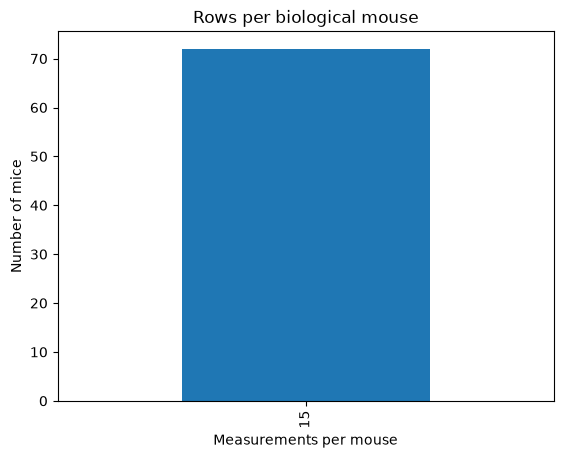

In [12]:
mice.groupby("mouse_id").size().value_counts().plot(kind="bar")
plt.xlabel("Measurements per mouse")
plt.ylabel("Number of mice")
plt.title("Rows per biological mouse")
plt.show()

**Plot 2 — Do proteins encoded in the trisomic region differ between Ts65Dn and Control?**

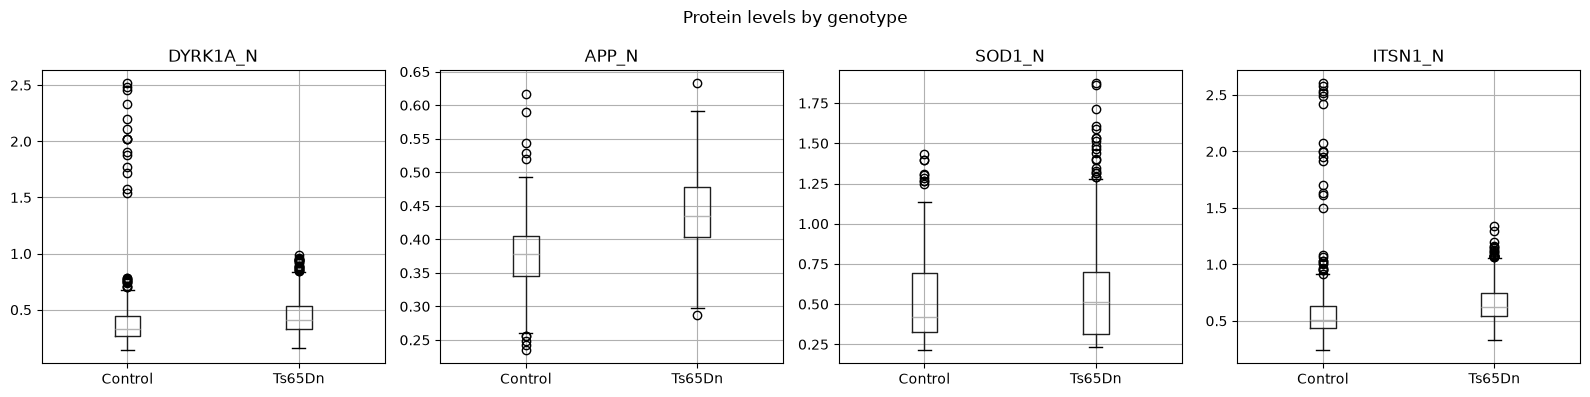

In [13]:
selected = ["DYRK1A_N", "APP_N", "SOD1_N", "ITSN1_N"]

fig, axes = plt.subplots(1, len(selected), figsize=(16, 4))
for ax, protein in zip(axes, selected):
    mice.boxplot(column=protein, by="Genotype", ax=ax)
    ax.set_title(protein)
    ax.set_xlabel("")
plt.suptitle("Protein levels by genotype")
plt.tight_layout()
plt.show()

**Plot 3 — Which experimental factor structures the protein profiles most: genotype, treatment or behavior?**

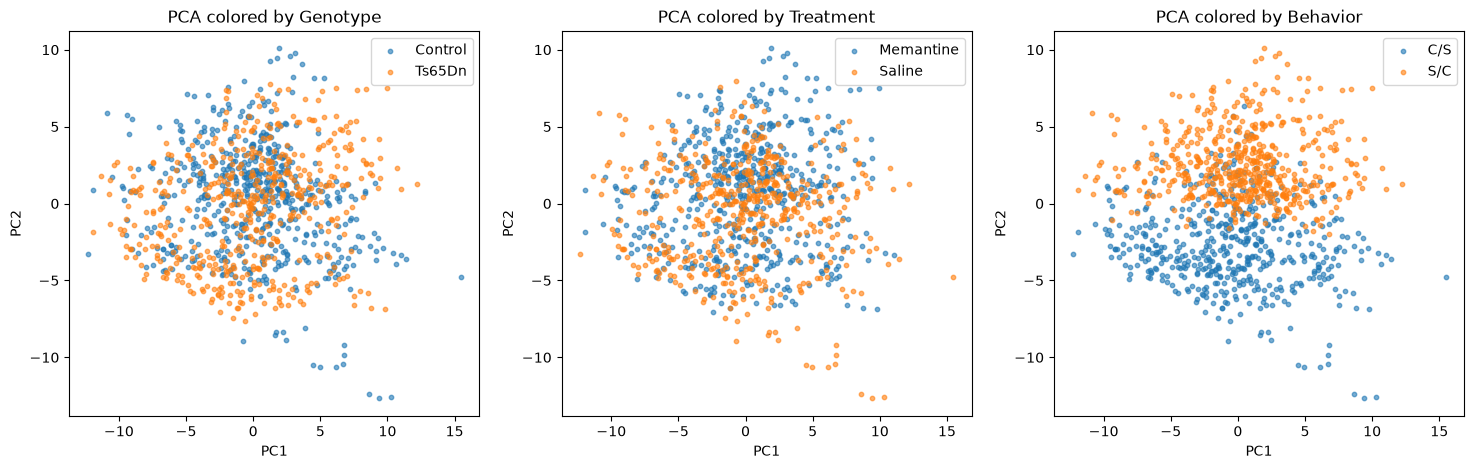

In [14]:
X_eda = mice[protein_cols].fillna(mice[protein_cols].median())
coords_m = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X_eda))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["Genotype", "Treatment", "Behavior"]):
    for label, idx in mice.groupby(col).groups.items():
        ax.scatter(coords_m[idx, 0], coords_m[idx, 1], label=label, s=10, alpha=0.6)
    ax.set_title(f"PCA colored by {col}")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend()
plt.show()

### 3.3 Diagnostics

Report checks for:
- missingness in proteins and metadata
- duplicate rows or duplicate measurement identifiers: 0 duplicate rows, 0 duplicate MouseID, 0 duplicate protein profiles (but the 15 measurements of one mouse are near-duplicates).
- expected 15 measurements per mouse: yes, all 72 mice have 15 rows.
- unusual categories or inconsistent labels
- non-finite, negative, or implausible expression values
- highly correlated or redundant protein variables: exclude 1 gen
- predictors that are deterministic parts of the target: class — its first letter (c/t) is the genotype so its excluded from X.

In [15]:
missing_by_col = mice[protein_cols].isna().sum().sort_values(ascending=False)

print("Missing in metadata:", mice[meta_cols].isna().sum().sum())
print("Missing protein cells:", missing_by_col.sum())
print("Proteins with any missing:", (missing_by_col > 0).sum(), "/", len(protein_cols))
missing_by_col[missing_by_col > 0].head(15)

Missing in metadata: 0
Missing protein cells: 1396
Proteins with any missing: 49 / 77


BCL2_N        285
H3MeK4_N      270
BAD_N         213
EGR1_N        210
H3AcK18_N     180
pCFOS_N        75
ELK_N          18
Bcatenin_N     18
MEK_N           7
P38_N           3
TRKA_N          3
RSK_N           3
APP_N           3
SOD1_N          3
MTOR_N          3
dtype: int64

In [16]:
missing_by_row = mice[protein_cols].isna().sum(axis=1)
print(missing_by_row.value_counts().sort_index())
missing_by_mouse = (mice[protein_cols].isna().groupby(mice["mouse_id"]).sum().sum(axis=1))
missing_by_mouse[missing_by_mouse > 0].sort_values(ascending=False).head(15)

0     552
1     165
2     120
3     117
4     104
5      19
43      3
Name: count, dtype: int64


mouse_id
3426      129
50810F     75
3479       64
3417       60
322        60
3605       60
3424       60
3420       60
3418       60
365        48
3419       45
294        45
3507       45
3416       45
364        45
dtype: int64

In [17]:
mice[protein_cols].isna().sum(axis=1).groupby(mice["Genotype"]).sum()

Genotype
Control    787
Ts65Dn     609
dtype: int64

In [18]:
print("Duplicate rows:", mice.duplicated().sum())
print("Duplicate MouseID:", mice["MouseID"].duplicated().sum())
print("Duplicate protein profiles:", mice[protein_cols].duplicated().sum())

Duplicate rows: 0
Duplicate MouseID: 0
Duplicate protein profiles: 0


In [19]:
for col in ["Genotype", "Treatment", "Behavior", "class"]:
    print(col, sorted(mice[col].unique()))

Genotype ['Control', 'Ts65Dn']
Treatment ['Memantine', 'Saline']
Behavior ['C/S', 'S/C']
class ['c-CS-m', 'c-CS-s', 'c-SC-m', 'c-SC-s', 't-CS-m', 't-CS-s', 't-SC-m', 't-SC-s']


In [20]:
vals = mice[protein_cols]
print("Non-finite:", (~np.isfinite(vals.fillna(0))).sum().sum())
print("Negative:", (vals < 0).sum().sum())
print("Zero:", (vals == 0).sum().sum())
vals[vals < 0].stack()

Non-finite: 0
Negative: 1
Zero: 0


0     DYRK1A_N    NaN
      ITSN1_N     NaN
      BDNF_N      NaN
      NR1_N       NaN
      NR2A_N      NaN
                   ..
1079  SYP_N       NaN
      H3AcK18_N   NaN
      EGR1_N      NaN
      H3MeK4_N    NaN
      CaNA_N      NaN
Length: 83160, dtype: float64

In [21]:
corr = mice[protein_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_pairs = upper.stack().sort_values(ascending=False)
print("Pairs with corr > 0.9:", (high_pairs > 0.9).sum())
high_pairs.head(10)

Pairs with corr > 0.9: 10


ARC_N     pS6_N         1.000000
DYRK1A_N  BRAF_N        0.959578
          ITSN1_N       0.959512
NR1_N     pNR1_N        0.947872
DYRK1A_N  pERK_N        0.945719
pERK_N    BRAF_N        0.926984
ITSN1_N   BRAF_N        0.917608
NR1_N     Bcatenin_N    0.914610
pNR1_N    pNR2B_N       0.906504
ITSN1_N   pERK_N        0.906289
dtype: float64

In [22]:
# Where do the extreme DYRK1A_N values come from?
mice.loc[mice["DYRK1A_N"] > 1.0].groupby(["mouse_id", "Genotype"]).size()

mouse_id  Genotype
3484      Control     15
dtype: int64

In [23]:
pd.crosstab(mice["class"], mice["Genotype"])

Genotype,Control,Ts65Dn
class,,
c-CS-m,150,0
c-CS-s,135,0
c-SC-m,150,0
c-SC-s,135,0
t-CS-m,0,135
t-CS-s,0,105
t-SC-m,0,135
t-SC-s,0,135


### 3.4 Preparation and feature roles

Selected supervised-learning question: can we predict the genotype (Control vs Ts65Dn) of a new, unseen mouse from the levels of 71 cortex proteins?

Missing-value decision:
- rule-based cleaning (before the split)
- the remaining missing cells are imputed with the median; the imputer is fitted on the training data only. Removing every row with any NaN would keep only about half of the rows, so imputation keeps more real measurements.
- mouse 3484 with extreme values is kept on purpose — no evidence of an error.

In [24]:
mice_clean = mice.copy()

mice_clean.loc[mice_clean["RRP1_N"] < 0, "RRP1_N"] = np.nan

mice_clean = mice_clean.drop(columns=["pS6_N"])

row_missing_frac = mice_clean[[c for c in protein_cols if c != "pS6_N"]].isna().mean(axis=1)
print("Rows removed:", mice_clean.loc[row_missing_frac > 0.5, "MouseID"].tolist())
mice_clean = mice_clean[row_missing_frac <= 0.5].reset_index(drop=True)

col_missing_frac = mice_clean.isna().mean()
drop_proteins = col_missing_frac[col_missing_frac > 0.10].index.tolist()
print("Proteins removed:", drop_proteins)
mice_clean = mice_clean.drop(columns=drop_proteins)

protein_cols_clean = [c for c in mice_clean.columns if c not in meta_cols]
print("Shape before:", mice.shape, "after:", mice_clean.shape)
print("Proteins left:", len(protein_cols_clean))
print("Remaining NaN:", mice_clean[protein_cols_clean].isna().sum().sum())

Rows removed: ['3426_13', '3426_14', '3426_15']
Proteins removed: ['BAD_N', 'BCL2_N', 'H3AcK18_N', 'EGR1_N', 'H3MeK4_N']
Shape before: (1080, 83) after: (1077, 77)
Proteins left: 71
Remaining NaN: 110


In [25]:
X_all = mice_clean[protein_cols_clean]
y_all = mice_clean["Genotype"]
groups = mice_clean["mouse_id"]

print("X:", X_all.shape, "y:", y_all.shape, "mice:", groups.nunique())

X: (1077, 71) y: (1077,) mice: 72


In [26]:
roles = pd.DataFrame({
    "column": ["MouseID", "mouse_id", "Genotype", "Treatment", "Behavior", "class",
               "71 proteins", "pS6_N", "BCL2_N, H3MeK4_N, BAD_N, EGR1_N, H3AcK18_N"],
    "role": ["measurement ID", "grouping variable", "target", "experimental condition",
             "experimental condition", "composite label", "features", "removed", "removed"],
    "in X": ["no", "no", "no (y)", "no", "no", "no", "yes", "no", "no"],
    "reason": [
        "identifies a row/record, not biology",
        "biological unit; used only for group split",
        "prediction target",
        "different scientific question i decided not to discover and possible leakage",
        "different scientific question",
        "contains Genotype -> target leakage",
        "protein expression levels",
        "identical to ARC_N (r = 1.0)",
        ">10% missing values",
    ],
})
roles

,column,role,in X,reason
0,MouseID,measurement ID,no,"identifies a row/record, not biology"
1,mouse_id,grouping variable,no,biological unit; used only for group split
2,Genotype,target,no (y),prediction target
3,Treatment,experimental condition,no,different scientific question i decided not to...
4,Behavior,experimental condition,no,different scientific question
5,class,composite label,no,contains Genotype -> target leakage
6,71 proteins,features,yes,protein expression levels
7,pS6_N,removed,no,identical to ARC_N (r = 1.0)
8,"BCL2_N, H3MeK4_N, BAD_N, EGR1_N, H3AcK18_N",removed,no,>10% missing values


### 3.5 Split strategy
- Independent biological unit: mouse
- Grouping variable: mouse_id
- Split method: StratifiedGroupKFold(n_splits=4), first fold used as test (25% of mice: 54 train / 18 test)

- **Population to generalize to:** new, unseen mice.
- **Why not a row-wise split:** the 15 measurements of one mouse are almost identical. With a random row split they would end up in both train and test, so the model would recognise the mouse instead of the genotype and the score would be over-optimistic.
- **Stratification:** used because the test set has only 18 mice and a random group split can give imbalanced classes. It is compatible with grouping because genotype is constant within a mouse. Result: 29 Control / 25 Ts65Dn mice in train, 9 / 9 in test.
- **Missing values:** median imputer fitted on X_train, then applied to X_test.

In [27]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
train_idx_m, test_idx_m = next(sgkf.split(X_all, y_all, groups=groups))

X_train = X_all.iloc[train_idx_m].copy()
X_test  = X_all.iloc[test_idx_m].copy()
y_train = y_all.iloc[train_idx_m].copy()
y_test  = y_all.iloc[test_idx_m].copy()

print("Train rows:", len(X_train), "| Test rows:", len(X_test))
print("Mouse overlap:", set(groups.iloc[train_idx_m]) & set(groups.iloc[test_idx_m]))
print("Mice per genotype, train:",mice_clean.iloc[train_idx_m].groupby("Genotype")["mouse_id"].nunique().to_dict())
print("Mice per genotype, test:",mice_clean.iloc[test_idx_m].groupby("Genotype")["mouse_id"].nunique().to_dict())

Train rows: 807 | Test rows: 270
Mouse overlap: set()
Mice per genotype, train: {'Control': 29, 'Ts65Dn': 25}
Mice per genotype, test: {'Control': 9, 'Ts65Dn': 9}


In [28]:
split_label = pd.Series("test", index=mice_clean.index)
split_label.iloc[train_idx_m] = "train"
print("Mice split across partitions:",(split_label.groupby(mice_clean["mouse_id"]).nunique() > 1).sum())

Mice split across partitions: 0


In [29]:
imputer_m = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer_m.fit_transform(X_train), columns=protein_cols_clean, index=X_train.index)
X_test  = pd.DataFrame(imputer_m.transform(X_test),columns=protein_cols_clean, index=X_test.index)

In [30]:
print("X_train:", X_train.shape,", X_test:", X_test.shape)
print("y_train:", y_train.value_counts().to_dict())
print("y_test:", y_test.value_counts().to_dict())

X_train: (807, 71) , X_test: (270, 71)
y_train: {'Control': 435, 'Ts65Dn': 372}
y_test: {'Control': 135, 'Ts65Dn': 135}


### 3.6 Confounding and distribution structure

Investigate associations between the target and:
- treatment 
- behavior 
- genotype 
- composite class 
- number of measurements per mouse.

In [31]:
mice_level = mice_clean.drop_duplicates("mouse_id")[["mouse_id", "Genotype", "Treatment", "Behavior", "class"]]
print("Mice:", len(mice_level))

Mice: 72


In [32]:
display(pd.crosstab(mice_level["Genotype"], mice_level["Treatment"], margins=True))
display(pd.crosstab(mice_level["Genotype"], mice_level["Behavior"], margins=True))

Treatment,Memantine,Saline,All
Genotype,,,
Control,20,18,38
Ts65Dn,18,16,34
All,38,34,72


Behavior,C/S,S/C,All
Genotype,,,
Control,19,19,38
Ts65Dn,16,18,34
All,35,37,72


In [33]:
pd.crosstab([mice_level["Genotype"], mice_level["Behavior"]], mice_level["Treatment"])

Treatment          Memantine  Saline
Genotype Behavior                   
Control  C/S              10       9
         S/C              10       9
Ts65Dn   C/S               9       7
         S/C               9       9

In [34]:
rows_per_mouse = mice_clean.groupby("mouse_id").size().rename("n_rows")
mice_level = mice_level.merge(rows_per_mouse, on="mouse_id")
print(mice_level.groupby("Genotype")["n_rows"].describe())
print(mice_level.groupby("class")["mouse_id"].count())

          count       mean       std   min   25%   50%   75%   max
Genotype                                                          
Control    38.0  15.000000  0.000000  15.0  15.0  15.0  15.0  15.0
Ts65Dn     34.0  14.911765  0.514496  12.0  15.0  15.0  15.0  15.0
class
c-CS-m    10
c-CS-s     9
c-SC-m    10
c-SC-s     9
t-CS-m     9
t-CS-s     7
t-SC-m     9
t-SC-s     9
Name: mouse_id, dtype: int64


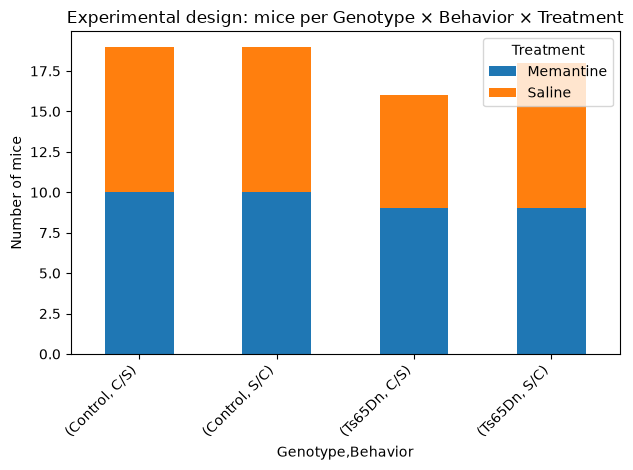

In [35]:
pd.crosstab([mice_level["Genotype"], mice_level["Behavior"]],mice_level["Treatment"]).plot(kind="bar", stacked=True)
plt.ylabel("Number of mice")
plt.title("Experimental design: mice per Genotype × Behavior × Treatment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Findings (counted per mouse, not per row)**
- **Are Treatment and Behavior balanced across genotype?**  yes (Treatment: 20/18 vs 18/16 mice; Behavior: 19/19 vs 16/18). 
- **Does class encode the target?** Yes, fully: the first letter (c/t) is the genotype. class is excluded from X as a direct leakage source.
- **Do groups contribute different numbers of rows?** Yes: 7–10 mice per class (105–150 rows); mouse 3426 has 12 rows after cleaning.
- **Could the model exploit design structure instead of protein biology?**
  - On PCA the strongest separation is by Behavior, not Genotype. Behavior is balanced, so it does not replace genotype directly.
  - Measurements of one mouse are very similar .
  - Subgroups are small (t-CS-s has only 7 mice), so with 18 test mice the score depends on which subgroups end up in test.

## 4. Summary

**ML question.** Predict mouse genotype (Control vs Ts65Dn) from 71 cortex protein levels for new, unseen mice. Binary classification, target = Genotype.

**Biological unit.** The mouse (mouse_id, 72 animals). One row is only one of 15 technical measurements of a mouse, so the real sample size is 72.

**Split strategy.** StratifiedGroupKFold by mouse_id: all measurements of a mouse stay in one partition, 54 mice in train / 18 in test, genotypes balanced. Final data: X_train (807, 71), X_test (270, 71).

**Potential source of bias.** Behavior is the strongest signal in the protein data, stronger than genotype. Also, class would leak the target if it were used as a feature.